# ShopSmart Retail: Executive Business Analysis
EDA, Correlation, and RFM Segmentation — reading directly from the local PostgreSQL database

## Setup & Database Connection


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")



DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME   = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    print("Connected to:", conn.engine.url.database)


Connected to: superstore


## Load Data From Postgres
Pulls the `orders`, `returns`, and `people` tables from Postgres server.

In [3]:
def load_data(engine):
    orders = pd.read_sql("SELECT * FROM orders;", engine)
    returns = pd.read_sql("SELECT * FROM returns;", engine)
    people = pd.read_sql("SELECT * FROM people;", engine)
    return orders, returns, people

orders_raw, returns_raw, people_raw = load_data(engine)
print(orders_raw.shape, returns_raw.shape, people_raw.shape)
orders_raw.head()


(74853, 20) (2450, 2) (4, 2)


,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country_region,city,state_province,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55
1,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49
2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27
3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77
4,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88


## Validate Data & Add Derived Fields
Run a quick sanity check (row count, nulls, dtypes) to confirm the data arrived as expected, then adds a few analysis-specific derived fields.

In [ ]:
def validate_and_prepare(orders):
    df = orders.copy()

    # Standardize column names in case Postgres returns mixed case
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("/", "_")
        .str.replace("-", "_")
    )

    df["order_date"] = pd.to_datetime(df["order_date"])
    df["ship_date"] = pd.to_datetime(df["ship_date"])

    # Sanity checks only. The ETL pipeline is responsible for actually fixing these.
    # If any of these print something unexpected, that's a signal to go check the pipeline.
    
    print(f"Row count: {len(df):,}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    print("Nulls in critical columns:")
    print(df[["order_id", "customer_id", "sales", "profit", "quantity"]].isnull().sum())
    print(f"Negative or zero quantity rows: {(df['quantity'] <= 0).sum()}")
    print(f"Negative sales rows: {(df['sales'] < 0).sum()}")

    # Derived fields (analysis-specific, not cleaning)
    df["delivery_days"] = (df["ship_date"] - df["order_date"]).dt.days
    df["profit_margin"] = df["profit"] / df["sales"].replace(0, np.nan)
    df["order_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

    return df


def prepare_returns(returns):
    df = returns.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df


orders = validate_and_prepare(orders_raw)
returns = prepare_returns(returns_raw)
orders.info()


Row count: 74,853
Duplicate rows: 0
Nulls in critical columns:
order_id       0
customer_id    0
sales          0
profit         0
quantity       0
dtype: int64
Negative or zero quantity rows: 0
Negative sales rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 74853 entries, 0 to 74852
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        74853 non-null  str           
 1   order_date      74853 non-null  datetime64[us]
 2   ship_date       74853 non-null  datetime64[us]
 3   ship_mode       74853 non-null  str           
 4   customer_id     74853 non-null  str           
 5   customer_name   74853 non-null  str           
 6   segment         74853 non-null  str           
 7   country_region  74853 non-null  str           
 8   city            74853 non-null  str           
 9   state_province  74853 non-null  str           
 10  postal_code     74853 non-null  str           
 11  reg

## Exploratory Data Analysis

In [5]:
cat_summary = (
    orders.groupby("category")
    .agg(
        total_revenue=("sales", "sum"),
        total_profit=("profit", "sum"),
        units_sold=("quantity", "sum"),
    )
    .assign(profit_margin_pct=lambda x: x.total_profit / x.total_revenue * 100)
    .sort_values("total_revenue", ascending=False)
)
cat_summary


,total_revenue,total_profit,units_sold,profit_margin_pct
category,,,,
Technology,"17,347,301.99","2,549,289.95",64140,14.70
Furniture,"7,404,930.19","-405,993.63",66234,-5.48
Office Supplies,"4,823,445.45","416,400.09",152481,8.63


In [6]:
monthly = orders.groupby("order_month")["sales"].sum().tail(12)
monthly


order_month
2026-01-01   548,035.99
2026-02-01   673,345.12
2026-03-01   633,594.53
2026-04-01   633,126.68
2026-05-01   645,852.62
2026-06-01   602,881.44
2026-07-01   625,870.38
2026-08-01   592,791.65
2026-09-01   669,916.95
2026-10-01   630,620.36
2026-11-01   671,189.55
2026-12-01   672,322.25
Name: sales, dtype: float64

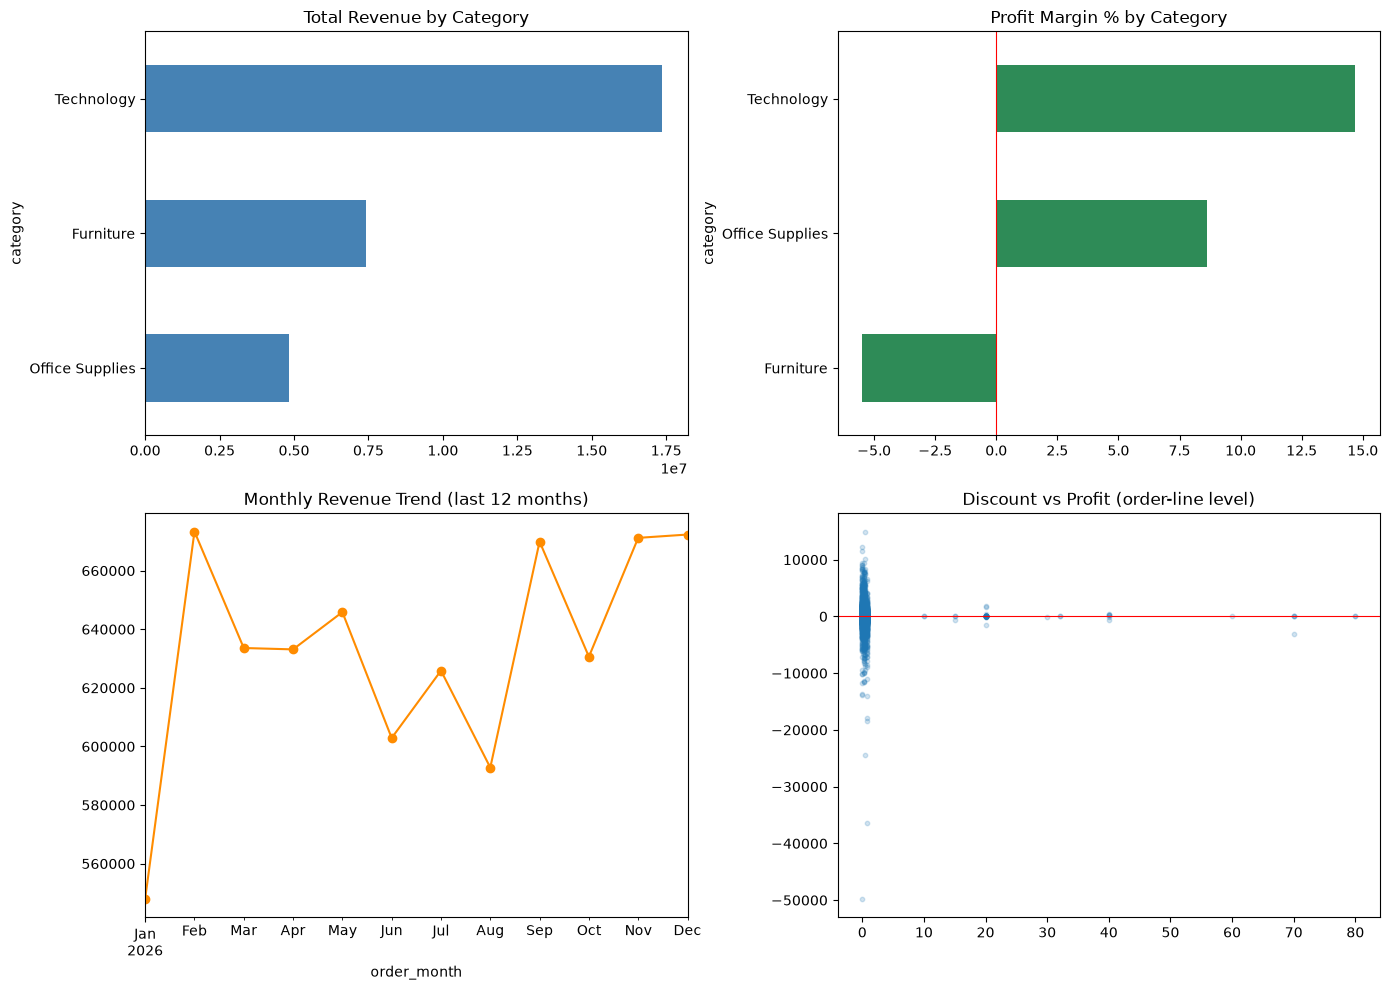

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_summary["total_revenue"].sort_values().plot(kind="barh", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Total Revenue by Category")

cat_summary["profit_margin_pct"].sort_values().plot(kind="barh", ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("Profit Margin % by Category")
axes[0, 1].axvline(0, color="red", linewidth=0.8)

monthly.plot(ax=axes[1, 0], marker="o", color="darkorange")
axes[1, 0].set_title("Monthly Revenue Trend (last 12 months)")

axes[1, 1].scatter(orders["discount"], orders["profit"], alpha=0.2, s=10)
axes[1, 1].set_title("Discount vs Profit (order-line level)")
axes[1, 1].axhline(0, color="red", linewidth=0.8)

plt.tight_layout()
plt.show()


## Correlation Analysis

In [8]:
corr = orders[["discount", "sales", "profit", "quantity"]].corr()
corr


,discount,sales,profit,quantity
discount,1.00,0.02,-0.01,0.00
sales,0.02,1.00,0.27,0.00
profit,-0.01,0.27,1.00,-0.00
quantity,0.00,0.00,-0.00,1.00


In [9]:
by_cat = orders.groupby("category").apply(lambda g: g["discount"].corr(g["profit"]))
by_cat.sort_values()


category
Furniture         -0.03
Technology        -0.02
Office Supplies   -0.01
dtype: float64

## RFM Customer Segmentation

In [10]:
snapshot_date = orders["order_date"].max() + pd.Timedelta(days=1)

rfm = orders.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("sales", "sum"),
)

rfm["r_score"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["rfm_score"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]

def segment(row):
    if row["rfm_score"] >= 10:
        return "Champions"
    elif row["rfm_score"] >= 8:
        return "Loyal Customers"
    elif row["rfm_score"] >= 6:
        return "Potential Loyalists"
    elif row["r_score"] <= 2 and row["f_score"] <= 2:
        return "At Risk"
    else:
        return "Needs Attention"

rfm["segment"] = rfm.apply(segment, axis=1)
rfm["segment"].value_counts()


segment
Potential Loyalists    245
Loyal Customers        239
Champions              168
At Risk                134
Needs Attention         18
Name: count, dtype: int64

In [11]:
rfm.groupby("segment")[["recency", "frequency", "monetary"]].mean()


,recency,frequency,monetary
segment,,,
At Risk,54.46,39.47,"25,810.05"
Champions,11.33,53.60,"48,809.50"
Loyal Customers,23.52,48.87,"40,146.97"
Needs Attention,22.83,38.89,"21,206.62"
Potential Loyalists,32.42,44.05,"32,409.35"


## Sales Forecasting


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

FORECAST_MONTHS = 3

def build_monthly_revenue(orders):
    monthly = orders.groupby("order_month")["sales"].sum().reset_index()
    monthly = monthly.sort_values("order_month").reset_index(drop=True)
    return monthly

def build_features(monthly):
    df = monthly.copy()
    df["t"] = np.arange(len(df))                  # linear trend index
    df["month_num"] = df["order_month"].dt.month  # 1-12, for seasonality
    month_dummies = pd.get_dummies(df["month_num"], prefix="m", drop_first=True)
    df = pd.concat([df, month_dummies], axis=1)
    return df

monthly_revenue = build_monthly_revenue(orders)
feat_df = build_features(monthly_revenue)
feature_cols = ["t"] + [c for c in feat_df.columns if c.startswith("m_")]
feat_df.head()


,order_month,sales,t,month_num,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12
0,2023-01-01,"585,838.52",0,1,False,False,False,False,False,False,False,False,False,False,False
1,2023-02-01,"515,832.14",1,2,True,False,False,False,False,False,False,False,False,False,False
2,2023-03-01,"623,972.36",2,3,False,True,False,False,False,False,False,False,False,False,False
3,2023-04-01,"617,901.59",3,4,False,False,True,False,False,False,False,False,False,False,False
4,2023-05-01,"490,539.07",4,5,False,False,False,True,False,False,False,False,False,False,False


### Backtest
Train on all but the last 3 months, then check the model against actuals which gives a defensible accuracy number to cite.

In [13]:
def train_test_split_time(df, holdout=3):
    return df.iloc[:-holdout], df.iloc[-holdout:]

train, test = train_test_split_time(feat_df, holdout=3)

model = LinearRegression()
model.fit(train[feature_cols], train["sales"])

test_pred = model.predict(test[feature_cols])
mae = mean_absolute_error(test["sales"], test_pred)
mape = mean_absolute_percentage_error(test["sales"], test_pred) * 100

for date, actual, pred in zip(test["order_month"], test["sales"], test_pred):
    print(f"{date.strftime('%Y-%m')}: actual= ${actual:,.0f}  predicted= ${pred:,.0f}")

print(f"\nMAE: ${mae:,.0f}   MAPE: {mape:.1f}%")


2026-10: actual= $630,620  predicted= $634,995
2026-11: actual= $671,190  predicted= $627,134
2026-12: actual= $672,322  predicted= $667,213

MAE: $17,846   MAPE: 2.7%


### Forward forecast

In [14]:
# Refit on full history for the actual forward forecast
full_model = LinearRegression()
full_model.fit(feat_df[feature_cols], feat_df["sales"])

last_t = feat_df["t"].max()
last_date = feat_df["order_month"].max()

future_dates = pd.date_range(last_date + pd.DateOffset(months=1), periods=FORECAST_MONTHS, freq="MS")
future = pd.DataFrame({
    "order_month": future_dates,
    "t": np.arange(last_t + 1, last_t + 1 + FORECAST_MONTHS),
    "month_num": future_dates.month,
})
month_dummies = pd.get_dummies(future["month_num"], prefix="m", drop_first=True)
for col in feature_cols:
    if col.startswith("m_") and col not in month_dummies.columns:
        month_dummies[col] = 0
future = pd.concat([future, month_dummies], axis=1)

future["forecast_sales"] = full_model.predict(future[feature_cols])
forecast = future[["order_month", "forecast_sales"]]
forecast


,order_month,forecast_sales
0,2027-01-01,"627,818.76"
1,2027-02-01,"616,573.19"
2,2027-03-01,"657,141.71"


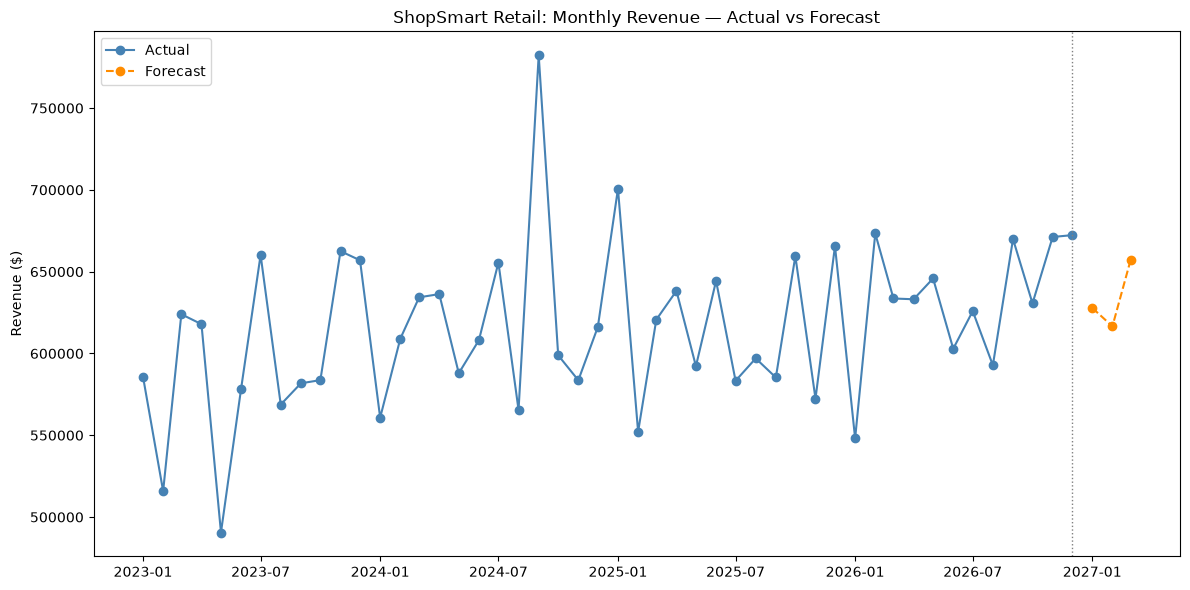

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue["order_month"], monthly_revenue["sales"], marker="o", label="Actual", color="steelblue")
plt.plot(forecast["order_month"], forecast["forecast_sales"], marker="o", linestyle="--", label="Forecast", color="darkorange")
plt.axvline(monthly_revenue["order_month"].max(), color="gray", linestyle=":", linewidth=1)
plt.title("ShopSmart Retail: Monthly Revenue — Actual vs Forecast")
plt.ylabel("Revenue ($)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
OUTDIR = "outputs"
os.makedirs(OUTDIR, exist_ok=True)  # creates the folder if it doesn't already exist

forecast.to_csv(f"{OUTDIR}/sales_forecast.csv", index=False)
print("Saved forecast values to", f"{OUTDIR}/sales_forecast.csv")


Saved forecast values to sales_forecast_output/sales_forecast.csv


## Save Outputs for Tableau

In [17]:
orders.to_csv(f"{OUTDIR}/orders_cleaned.csv", index=False)
rfm.to_csv(f"{OUTDIR}/customer_rfm_segments.csv")
print("Saved cleaned orders and RFM segments to", OUTDIR)


Saved cleaned orders and RFM segments to sales_forecast_output
